# 📓 Notebook 1 — User Clarification & Research Brief Generation

> **Goal of this notebook:** build the *scoping* phase of a deep research agent.
> Before searching anything, the agent must understand *exactly* what the user wants.

---

## 🗺️ The big picture

Here is the full 3-phase research pipeline we are building across all 3 notebooks:

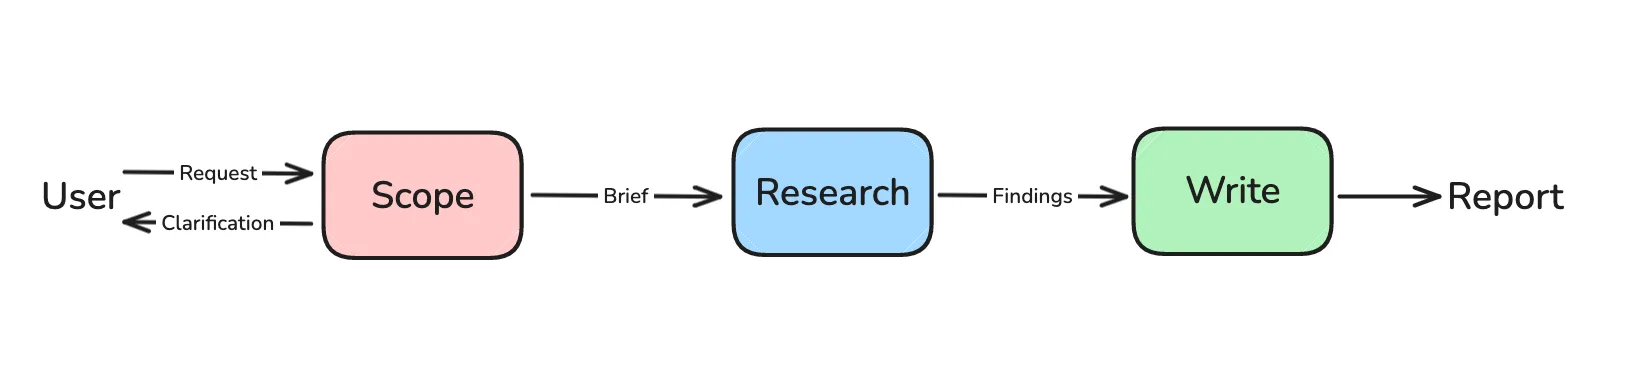

**This notebook covers Phase 1 — Scope**, which itself has two steps:

| Step | What it does |
|---|---|
| **1. Clarify** | Ask the user a follow-up question if the request is too vague |
| **2. Brief** | Distil the conversation into a clean research specification |

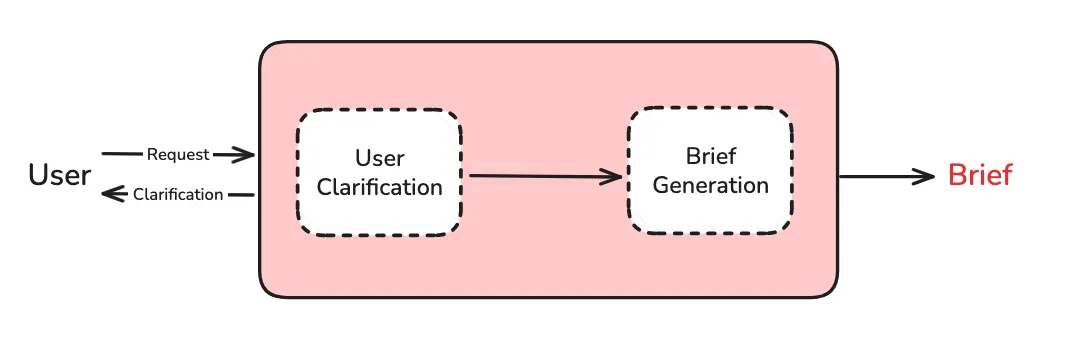

---

## 🗂️ Notebook structure

We will build this in the following order — going from *concept → code* at each step:

1. ⚙️ Setup & imports
2. 📋 Structured output — making the LLM fill a form
3. 📦 State — the shared clipboard of the workflow
4. 💬 The prompts — instructions we give the LLM
5. ⚡ The two workflow nodes
6. 🔗 Graph construction & compilation
7. 🚀 Run it live & inspect the result

---
## ⚙️ Step 0 — Setup

Run this cell first every time you open the notebook. It sets your API keys so all libraries can find them automatically.

In [1]:
# ============================================================
# 🔑  Enter your API keys here before running the notebook
# ============================================================
import os

# Get your FREE Groq API key at: https://console.groq.com
GROQ_API_KEY = ""

# Get your free LangSmith key at: https://smith.langchain.com/
LANGSMITH_API_KEY = ""
LANGSMITH_TRACING = "true"
LANGSMITH_PROJECT = "deep_research_new"

# Inject into environment so LangChain / LangSmith pick them up automatically
os.environ["GROQ_API_KEY"]      = GROQ_API_KEY
os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
os.environ["LANGSMITH_TRACING"] = LANGSMITH_TRACING
os.environ["LANGSMITH_PROJECT"] = LANGSMITH_PROJECT

%load_ext autoreload
%autoreload 2

print("✅ API keys configured!")

✅ API keys configured!


---
## 📋 Step 1 — Structured Output

> **Why this first?** Everything else in this notebook depends on this idea.
> State, nodes, and the graph all make more sense once you understand structured output.

### The problem: LLMs return unpredictable text

If you ask an LLM *"Do we need more information from the user?"*, it might return any of these:

```
"Yes, I think we need more clarification about the scope."
"Clarification needed: true."
"After careful consideration, additional context would be beneficial..."
"No."
```

Now try writing `if response == True:` — you can't.
You'd need fragile regex, string matching, and it would break constantly.

### The solution: force the LLM to fill a form

Instead of asking for free text, you define a **Pydantic schema** — a typed form with fixed fields.
The LLM *must* return an object matching that schema. No essays. No surprises.

```
model.with_structured_output(MySchema)  ← attaches the form to the model
```

The response is then a normal Python object with real typed attributes you can use directly in code.

### 🧪 Let's see it in action — raw text vs structured output

First, let's call the model **without** structured output and see what we get.

In [2]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

# Initialize the model
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.0)

# ── Raw call — no schema ──────────────────────────────────────
raw_response = model.invoke([
    HumanMessage(content="Do we need more information from the user who asked: 'I want to research coffee shops'? Answer yes or no and explain why.")
])

print("TYPE:", type(raw_response))
print()
print("CONTENT:", raw_response.content)

TYPE: <class 'langchain_core.messages.ai.AIMessage'>

CONTENT: Yes. 

The user's request 'I want to research coffee shops' is quite broad and doesn't provide enough information to give a specific and helpful response. To provide a more accurate and relevant answer, more details would be needed, such as: 
- What aspect of coffee shops do they want to research (e.g. business model, marketing strategies, customer behavior, etc.)?
- Are they looking for information on a specific geographic location or type of coffee shop?
- Are there any particular goals or objectives for their research (e.g. opening their own coffee shop, investing in the industry, etc.)? 

Without this additional information, it would be difficult to provide a meaningful and targeted response to their request.


### Now with structured output — the LLM fills a form

We define a Pydantic class with the exact fields we need, then attach it to the model.

In [3]:
from pydantic import BaseModel, Field

# Define the "form" — exactly what fields we need from the LLM
class ClarifyDecision(BaseModel):
    """Simple schema to test structured output."""
    need_clarification: bool = Field(
        description="True if the user request is too vague to research, False if it is clear enough."
    )
    reason: str = Field(
        description="One sentence explaining the decision."
    )

# Attach the form to the model
structured_model = model.with_structured_output(ClarifyDecision)

# Invoke — response is now a ClarifyDecision object, not raw text
response = structured_model.invoke([
    HumanMessage(content="Do we need more information from the user who asked: 'I want to research coffee shops'?")
])

print("TYPE:", type(response))
print()
print("need_clarification:", response.need_clarification)  # ← real Python bool!
print("reason           :", response.reason)
print()
print("We can now write:")
print(f"  if response.need_clarification:  →  {response.need_clarification}")

TYPE: <class '__main__.ClarifyDecision'>

need_clarification: True
reason           : The user's request is too vague as it does not specify what aspect of coffee shops they want to research.

We can now write:
  if response.need_clarification:  →  True


### 🔑 Key takeaway

| Without structured output | With structured output |
|---|---|
| Returns raw text string | Returns a typed Python object |
| Unpredictable format | Always matches your schema |
| Requires regex / parsing | Use like any Python object: `response.need_clarification` |
| Breaks silently | Retries automatically if schema not matched |

> **The `Field(description=...)` is not a Python comment** — it gets sent to the LLM as part of the instructions.
> It tells the model *what this field means* and *when to set it to true or false*.
> Better descriptions → better, more consistent LLM decisions.

---
## 📦 Step 2 — State: the shared clipboard

### The problem: how does information travel between nodes?

Our workflow has two functions: `clarify_with_user` and `write_research_brief`.
The second one needs to know what the conversation said — but the two functions don't call each other directly.
There is a **graph** between them.

> 🏥 **Analogy:** Think of a hospital ward where multiple doctors treat the same patient across different shifts.
> There's a whiteboard at the end of the bed — every doctor reads it before acting and writes their findings after.
> No doctor calls another directly. The whiteboard *is* the communication channel.
> `AgentState` is that whiteboard.

### Two classes — different purposes

| Class | Purpose |
|---|---|
| `AgentState` | The full whiteboard — all fields the graph can read and write |
| `AgentInputState` | The front door — only what the *user* is allowed to pass in |

Why two? `AgentState` has internal fields like `research_brief`, `raw_notes`, `final_report`.
Users should only provide `messages`. `AgentInputState` is a restricted view that prevents users from accidentally filling internal fields.

### The schemas we will need later

We also define the two Pydantic schemas that the LLM will fill in the workflow nodes.
We saw the concept above — now here are the real ones used by the agent:

| Schema | Used by | What it captures |
|---|---|---|
| `ClarifyWithUser` | Node 1 | Routing decision + question or confirmation |
| `ResearchQuestion` | Node 2 | The final research brief |

In [4]:
%%writefile ../src/deep_research_from_scratch/state_scope.py

"""State Definitions and Pydantic Schemas for Research Scoping."""

import operator
from typing_extensions import Optional, Annotated, Sequence

from langchain_core.messages import BaseMessage
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field


# ══════════════════════════════════════════════════════
# STATE DEFINITIONS — the whiteboard
# ══════════════════════════════════════════════════════

class AgentInputState(MessagesState):
    """What the USER provides: only the conversation messages."""
    pass


class AgentState(MessagesState):
    """The full internal whiteboard — read and written by every node.

    Fields marked with operator.add are MERGED (not overwritten) when
    multiple parallel agents write to them at the same time.
    """

    # ── Phase 1: Scoping ─────────────────────────────────────────
    # Written by write_research_brief, read by Phase 2 agents
    research_brief: Optional[str]

    # ── Phase 2: Research coordination ──────────────────────────
    # Uses add_messages → new messages are appended, never replaced
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages]

    # Uses operator.add → lists from parallel agents are concatenated
    raw_notes: Annotated[list[str], operator.add] = []
    notes:     Annotated[list[str], operator.add] = []

    # ── Phase 3: Output ──────────────────────────────────────────
    final_report: str


# ══════════════════════════════════════════════════════
# STRUCTURED OUTPUT SCHEMAS — the forms
# ══════════════════════════════════════════════════════

class ClarifyWithUser(BaseModel):
    """Form filled by the LLM in Node 1 — routing decision + message."""

    need_clarification: bool = Field(
        description="True if the user request is too vague to research. False if we have enough to proceed.",
    )
    question: str = Field(
        description="The clarifying question to show the user if need_clarification is True.",
    )
    verification: str = Field(
        description="A friendly confirmation shown to the user when need_clarification is False.",
    )


class ResearchQuestion(BaseModel):
    """Form filled by the LLM in Node 2 — the research brief."""

    research_brief: str = Field(
        description="A detailed research specification distilled from the full conversation history.",
    )

Overwriting ../src/deep_research_from_scratch/state_scope.py


### 🔍 Inspect the state fields interactively

Let's look at what `AgentState` actually contains.

In [6]:
from deep_research_from_scratch.state_scope import AgentState, AgentInputState, ClarifyWithUser, ResearchQuestion
import inspect

# Show all fields defined on AgentState
print("AgentState fields:")
print("-" * 50)
hints = AgentState.__annotations__
for field, ftype in hints.items():
    print(f"  {field:<25} {str(ftype)}")

print()
print("AgentInputState fields (what the user provides):")
print("-" * 50)
for field, ftype in AgentInputState.__annotations__.items():
    print(f"  {field:<25} {str(ftype)}")

AgentState fields:
--------------------------------------------------
  messages                  ForwardRef('Annotated[list[AnyMessage], add_messages]', module='langgraph.graph.message')
  research_brief            typing.Optional[str]
  supervisor_messages       typing.Annotated[typing.Sequence[langchain_core.messages.base.BaseMessage], <function _add_messages_wrapper.<locals>._add_messages at 0x0000021BFA5389A0>]
  raw_notes                 typing.Annotated[list[str], <built-in function add>]
  notes                     typing.Annotated[list[str], <built-in function add>]
  final_report              <class 'str'>

AgentInputState fields (what the user provides):
--------------------------------------------------
  messages                  ForwardRef('Annotated[list[AnyMessage], add_messages]', module='langgraph.graph.message')


### ⚠️ The `operator.add` reducer — why it matters for parallel agents

This is the most subtle line in the state definition:

```python
raw_notes: Annotated[list[str], operator.add] = []
```

**What happens when two research agents write to `raw_notes` at the same time?**

- **Without `operator.add`** → last write wins. One agent's notes are lost forever.
- **With `operator.add`** → the lists are *concatenated*. Both agents' notes survive.

This one annotation is what makes safe parallel research possible in Notebook 4.

In [7]:
import operator

# Simulate what LangGraph does when merging two parallel writes
agent_a_notes = ["Coffee quality is excellent at Ritual Roasters"]
agent_b_notes = ["Blue Bottle has the best espresso bar in the Mission"]

# Without operator.add → one overwrites the other
print("❌ Without reducer (last write wins):")
result = agent_b_notes   # agent_a's work is simply gone
print(" ", result)

print()

# With operator.add → lists are merged
print("✅ With operator.add (concatenated):")
result = operator.add(agent_a_notes, agent_b_notes)
print(" ", result)

❌ Without reducer (last write wins):
  ['Blue Bottle has the best espresso bar in the Mission']

✅ With operator.add (concatenated):
  ['Coffee quality is excellent at Ritual Roasters', 'Blue Bottle has the best espresso bar in the Mission']


---
## 💬 Step 3 — The Prompts

A **prompt** is the instruction document we hand to the LLM at each step.
It has placeholder holes like `{messages}` and `{date}` that get filled with real data at runtime.

> **Why store prompts in a separate file (`prompts.py`)?**
> The same prompt is reused across Notebooks 1–5.
> One source of truth — change it once, all notebooks update.

In [8]:
# Display the prompt template used in Node 1 (clarification decision)
from utils import show_prompt
from deep_research_from_scratch.prompts import clarify_with_user_instructions

show_prompt(clarify_with_user_instructions, "Clarify with User Instructions")

╭──────────────────────────────────────── Clarify with User Instructions ─────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  These are the messages that have been exchanged so far from the user asking for the report:                    │
│  <Messages>                                                                                                     │
│  {messages}                                                                                                     │
│  </Messages>                                                                                                    │
│                                                                                                                 │
│  Today's date is {date}.                                                                                        │
│                                                                                                                 │
│  Assess whether you need to ask a clarifying question, or if the user has already provided enough information   │
│  for you to start research.                                                                                     │
│  IMPORTANT: If you can see in the messages history that you have already asked a clarifying question, you       │
│  almost always do not need to ask another one. Only ask another question if ABSOLUTELY NECESSARY.               │
│                                                                                                                 │
│  If there are acronyms, abbreviations, or unknown terms, ask the user to clarify.                               │
│  If you need to ask a question, follow these guidelines:                                                        │
│  - Be concise while gathering all necessary information                                                         │
│  - Make sure to gather all the information needed to carry out the research task in a concise, well-structured  │
│  manner.                                                                                                        │
│  - Use bullet points or numbered lists if appropriate for clarity. Make sure that this uses markdown            │
│  formatting and will be rendered correctly if the string output is passed to a markdown renderer.               │
│  - Don't ask for unnecessary information, or information that the user has already provided. If you can see     │
│  that the user has already provided the information, do not ask for it again.                                   │
│                                                                                                                 │
│  Respond in valid JSON format with these exact keys:                                                            │
│  "need_clarification": boolean,                                                                                 │
│  "question": "<question to ask the user to clarify the report scope>",                                          │
│  "verification": "<verification message that we will start research>"                                           │
│                                                                                                                 │
│  If you need to ask a clarifying question, return:                                                              │
│  "need_clarification": true,                                                                                    │
│  "question": "<your clarifying question>",                                                                      │
│  "verification": ""                                                                                             │
│                                                       

### What to notice in this prompt

- **`{messages}`** — the full conversation history, formatted as readable text
- **`{date}`** — today's date, so the LLM knows what "recent" means
- The prompt instructs the LLM to return a structured decision — it pairs directly with `ClarifyWithUser`

> **Try this:** change the date to a year in the past and re-run Node 1.
> The LLM's sense of "recent sources" will shift — that's how much the date matters.

In [9]:
# Also display the prompt used in Node 2 (brief generation)
from deep_research_from_scratch.prompts import transform_messages_into_research_topic_prompt

show_prompt(transform_messages_into_research_topic_prompt, "Transform Messages → Research Brief")

╭────────────────────────────────────── Transform Messages → Research Brief ──────────────────────────────────────╮
│                                                                                                                 │
│  You will be given a set of messages that have been exchanged so far between yourself and the user.             │
│  Your job is to translate these messages into a more detailed and concrete research question that will be used  │
│  to guide the research.                                                                                         │
│                                                                                                                 │
│  The messages that have been exchanged so far between yourself and the user are:                                │
│  <Messages>                                                                                                     │
│  {messages}                                                                                                     │
│  </Messages>                                                                                                    │
│                                                                                                                 │
│  Today's date is {date}.                                                                                        │
│                                                                                                                 │
│  You will return a single research question that will be used to guide the research.                            │
│                                                                                                                 │
│  Guidelines:                                                                                                    │
│  1. Maximize Specificity and Detail                                                                             │
│  - Include all known user preferences and explicitly list key attributes or dimensions to consider.             │
│  - It is important that all details from the user are included in the instructions.                             │
│                                                                                                                 │
│  2. Handle Unstated Dimensions Carefully                                                                        │
│  - When research quality requires considering additional dimensions that the user hasn't specified,             │
│  acknowledge them as open considerations rather than assumed preferences.                                       │
│  - Example: Instead of assuming "budget-friendly options," say "consider all price ranges unless cost           │
│  constraints are specified."                                                                                    │
│  - Only mention dimensions that are genuinely necessary for comprehensive research in that domain.              │
│                                                                                                                 │
│  3. Avoid Unwarranted Assumptions                                                                               │
│  - Never invent specific user preferences, constraints, or requirements that weren't stated.                    │
│  - If the user hasn't provided a particular detail, explicitly note this lack of specification.                 │
│  - Guide the researcher to treat unspecified aspects as flexible rather than making assumptions.                │
│                                                                                                                 │
│  4. Distinguish Between Research Scope and User Preferences                                                     │
│  - Research scope: What topics/dimensions should be investigated (can be broader than user's explicit           │
│  mentions)                                            

---
## ⚡ Step 4 — The Two Workflow Nodes

A **node** is just a Python function that the graph executes.
Every node does the same three things:

```
1. Read from state   →   2. Call the LLM   →   3. Write back to state
```

We have two nodes:
- **`clarify_with_user`** — decides if we need more info, routes accordingly
- **`write_research_brief`** — distils the conversation into a clean research brief

### Node 1 — `clarify_with_user`

This node introduces a new concept: the **`Command` object**.

Normally a node returns a dict that gets merged into state.
But here the node also needs to *decide where to go next* — either ask the user (→ END) or proceed (→ write_research_brief).

A `Command` does both at once:

```python
return Command(
    goto="write_research_brief",          # ← routing decision
    update={"messages": [AIMessage(...)]} # ← state update
)
```

In [10]:
%%writefile ../src/deep_research_from_scratch/research_agent_scope.py

"""Workflow nodes for the scoping phase — clarification and brief generation."""

from datetime import datetime
from typing_extensions import Literal

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, get_buffer_string
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

from deep_research_from_scratch.prompts import (
    clarify_with_user_instructions,
    transform_messages_into_research_topic_prompt,
)
from deep_research_from_scratch.state_scope import (
    AgentState, AgentInputState,
    ClarifyWithUser, ResearchQuestion,
)


# ── Utility ──────────────────────────────────────────────────
def get_today_str() -> str:
    """Return today's date as a readable string (Windows-safe)."""
    return datetime.now().strftime("%a %b %d, %Y").replace(" 0", " ")


# ── Model ────────────────────────────────────────────────────
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.0)


# ══════════════════════════════════════════════════════
# NODE 1 — clarify_with_user
# Purpose : decide if we need more info from the user
# Reads   : state["messages"]
# Writes  : a new AIMessage (question OR confirmation)
# Routes  : END (ask user) or write_research_brief (proceed)
# ══════════════════════════════════════════════════════

def clarify_with_user(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:

    # Step 1 — attach the schema (the "form") to the model
    structured_model = model.with_structured_output(ClarifyWithUser)

    # Step 2 — invoke with the prompt filled from state
    response = structured_model.invoke([
        HumanMessage(content=clarify_with_user_instructions.format(
            messages=get_buffer_string(messages=state["messages"]),
            date=get_today_str()
        ))
    ])
    # response is now a ClarifyWithUser object — not raw text

    # Step 3 — route based on the bool field
    if response.need_clarification:
        # Not enough info → stop and show the question to the user
        return Command(
            goto=END,
            update={"messages": [AIMessage(content=response.question)]}
        )
    else:
        # Enough info → continue to write the brief
        return Command(
            goto="write_research_brief",
            update={"messages": [AIMessage(content=response.verification)]}
        )


# ══════════════════════════════════════════════════════
# NODE 2 — write_research_brief
# Purpose : distil the conversation into a research brief
# Reads   : state["messages"]  (the full conversation)
# Writes  : research_brief, supervisor_messages
# Routes  : always → END  (no decision needed, plain dict return)
# ══════════════════════════════════════════════════════

def write_research_brief(state: AgentState):

    # Step 1 — attach the schema
    structured_model = model.with_structured_output(ResearchQuestion)

    # Step 2 — invoke with the full conversation history
    response = structured_model.invoke([
        HumanMessage(content=transform_messages_into_research_topic_prompt.format(
            messages=get_buffer_string(state.get("messages", [])),
            date=get_today_str()
        ))
    ])

    # Step 3 — write to state (plain dict, no routing decision needed)
    return {
        "research_brief": response.research_brief,
        # Also forward the brief to Phase 2 via supervisor_messages
        "supervisor_messages": [HumanMessage(content=f"{response.research_brief}.")]
    }


# ══════════════════════════════════════════════════════
# GRAPH CONSTRUCTION — wire the nodes together
# ══════════════════════════════════════════════════════

deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

deep_researcher_builder.add_node("clarify_with_user",    clarify_with_user)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)

deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", END)

# Compile without checkpointer (used when importing into later notebooks)
scope_research = deep_researcher_builder.compile()

Overwriting ../src/deep_research_from_scratch/research_agent_scope.py


### 🔍 Inspect Node 1 step by step — before running the full graph

Let's call `clarify_with_user` logic manually to see exactly what the LLM returns.

In [11]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, get_buffer_string
from deep_research_from_scratch.state_scope import ClarifyWithUser
from deep_research_from_scratch.prompts import clarify_with_user_instructions
from datetime import datetime

model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.0)
structured_model = model.with_structured_output(ClarifyWithUser)

def get_today_str():
    return datetime.now().strftime("%a %b %d, %Y").replace(" 0", " ")

# ── Test with a VAGUE request ─────────────────────────────────
vague_message = [HumanMessage(content="I want to research coffee shops.")]

response = structured_model.invoke([
    HumanMessage(content=clarify_with_user_instructions.format(
        messages=get_buffer_string(vague_message),
        date=get_today_str()
    ))
])

print("=== VAGUE INPUT ===")
print(f"need_clarification : {response.need_clarification}")
print(f"question           : {response.question}")
print(f"verification       : {response.verification}")

=== VAGUE INPUT ===
need_clarification : True
question           : What specific aspects of coffee shops would you like to research (e.g. * location, * menu, * reviews, * business model)?
verification       : 


In [13]:
# ── Test with a DETAILED request ─────────────────────────────
detailed_message = [HumanMessage(
    content="Let's examine coffee quality to assess the best specialty coffee shops in San Francisco. "
        "Focus on multi-roaster and single-origin shops across the Mission, Soma, and Hayes Valley districts. "
        "Evaluate quality based on green bean sourcing transparency, SCA (Specialty Coffee Association) "
        "cupping scores above 85, roasting consistency (light-to-medium profiles), and barista extraction "
        "precision for both espresso and pour-over methods."
)]

response = structured_model.invoke([
    HumanMessage(content=clarify_with_user_instructions.format(
        messages=get_buffer_string(detailed_message),
        date=get_today_str()
    ))
])

print("=== DETAILED INPUT ===")
print(f"need_clarification : {response.need_clarification}")
print(f"question           : {response.question}")
print(f"verification       : {response.verification}")

=== DETAILED INPUT ===
need_clarification : False
question           : 
verification       : I have sufficient information to proceed. I understand that you want to assess the best specialty coffee shops in San Francisco, focusing on multi-roaster and single-origin shops in the Mission, Soma, and Hayes Valley districts. The evaluation will be based on green bean sourcing transparency, SCA cupping scores above 85, roasting consistency, and barista extraction precision for both espresso and pour-over methods. I will now begin the research process.


### 🔍 Inspect Node 2 step by step — before running the full graph

Let's also call `write_research_brief` logic manually to see what the brief looks like.

In [14]:
from deep_research_from_scratch.state_scope import ResearchQuestion
from deep_research_from_scratch.prompts import transform_messages_into_research_topic_prompt
from langchain_core.messages import AIMessage

# Simulate a full conversation (user + agent clarification exchange)
full_conversation = [
    HumanMessage(content="I want to research coffee shops."),
    AIMessage(content="Could you specify which city and what aspect — quality, price, atmosphere?"),
    HumanMessage(content="Specialty coffee quality in San Francisco please."),
]

structured_model_brief = model.with_structured_output(ResearchQuestion)

response = structured_model_brief.invoke([
    HumanMessage(content=transform_messages_into_research_topic_prompt.format(
        messages=get_buffer_string(full_conversation),
        date=get_today_str()
    ))
])

print("=== RESEARCH BRIEF ===")
print(response.research_brief)

=== RESEARCH BRIEF ===
As I am looking to research specialty coffee quality in San Francisco, I would like to investigate various factors that contribute to the quality of specialty coffee, including but not limited to bean sourcing, roasting methods, brewing techniques, and barista expertise. I am interested in considering all price ranges unless cost constraints are specified. My primary focus is on the taste of the coffee. I would like to prioritize official websites of coffee shops, reputable review platforms, and primary sources for this research. Please guide the research to treat unspecified aspects, such as atmosphere and amenities, as flexible rather than making assumptions, and consider multiple sources to ensure a comprehensive understanding of specialty coffee quality in San Francisco.


---
## 🔗 Step 5 — Graph Construction & Compilation

We now wire everything together into a **LangGraph StateGraph**.

The graph is the orchestrator: it holds the nodes, the edges between them,
and the shared state that passes through everything.

> **Analogy:** `add_node` = write the recipe steps. `add_edge` = draw arrows between them.
> `compile()` = hand the recipe to the kitchen — validate it and make it executable.

### Why compile with `InMemorySaver` (the checkpointer)?

Without a checkpointer, each `scope.invoke()` is a **fresh start** — no memory of previous calls.
With `InMemorySaver` + a **`thread_id`**, the graph remembers the conversation across calls.

| Without checkpointer | With checkpointer |
|---|---|
| Call 2 has no idea what Call 1 said | Call 2 sees the full history from Call 1 |
| Every call is a blank slate | Same `thread_id` = same conversation |

Graph structure:


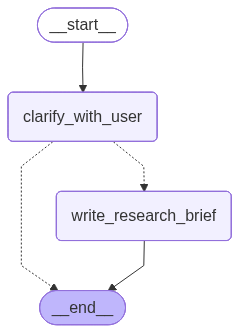

In [15]:
# Import the builder we saved with %%writefile above
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research_from_scratch.research_agent_scope import deep_researcher_builder

# Compile WITH a checkpointer — enables memory across invocations
checkpointer = InMemorySaver()
scope = deep_researcher_builder.compile(checkpointer=checkpointer)

# Visualise the graph — this IS the flowchart we drew in the theory section
print("Graph structure:")
display(Image(scope.get_graph(xray=True).draw_mermaid_png()))

**Read the diagram carefully.**

- `START` → `clarify_with_user` is a static edge (always happens)
- `clarify_with_user` → `END` or → `write_research_brief` is dynamic (decided by the node at runtime)
- `write_research_brief` → `END` is a static edge (always happens)

This maps exactly to the two `Command` branches we wrote in Node 1.

---
## 🚀 Step 6 — Run it live

Now we run the full graph end-to-end with two carefully chosen inputs.

**The plan:**
1. First call: a **vague** request → expect the agent to ask for clarification
2. Second call: a **detailed** reply → expect the agent to write the brief

Both calls use the **same `thread_id`** so the graph sees them as one continuous conversation.

In [16]:
from utils import format_messages
from langchain_core.messages import HumanMessage

# thread_id ties multiple calls into one conversation in the checkpointer
thread = {"configurable": {"thread_id": "1"}}

# ── Call 1: vague input ───────────────────────────────────────
print("=" * 55)
print("CALL 1 — Vague request")
print("=" * 55)
result = scope.invoke(
    {"messages": [HumanMessage(content="I want to research coffee shops.")]},
    config=thread
)
format_messages(result['messages'])

CALL 1 — Vague request


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research coffee shops.                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ What specific aspects of coffee shops would you like to research (e.g. * location, * menu, * reviews, *         │
│ business model)?                                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**What happened?**

The agent ran `clarify_with_user`, the LLM filled the `ClarifyWithUser` form with `need_clarification=True`,
and the `Command` sent the graph to `END` — returning the question to the user.

Now let's reply with a detailed answer **in the same thread**.

In [17]:
# ── Call 2: detailed reply in the same thread ────────────────
print("=" * 55)
print("CALL 2 — Detailed reply (same thread_id='1')")
print("=" * 55)
result = scope.invoke(
    {"messages": [HumanMessage(
        content="Let's examine coffee quality to assess the best specialty coffee shops in San Francisco."
    )]},
    config=thread
)
format_messages(result['messages'])

CALL 2 — Detailed reply (same thread_id='1')


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research coffee shops.                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ What specific aspects of coffee shops would you like to research (e.g. * location, * menu, * reviews, *         │
│ business model)?                                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Let's examine coffee quality to assess the best specialty coffee shops in San Francisco.                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I have sufficient information to proceed. You would like to research the best specialty coffee shops in San     │
│ Francisco, focusing on coffee quality. I will now begin the research process to provide you with the relevant   │
│ information.                                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**What happened this time?**

The graph picked up the conversation where it left off.
The LLM saw **all three messages** (original request + agent question + detailed reply) and decided it now had enough.
`need_clarification=False` → the `Command` routed to `write_research_brief` → the brief was written.

### 🔬 Make the invisible State visible

The graph returned `result` — which is the final `AgentState`.
Let's inspect what's inside.

In [18]:
# Inspect the keys of the final state
print("Keys in the final state:")
print(list(result.keys()))
print()

# How many messages accumulated across both calls?
print(f"Total messages in conversation: {len(result['messages'])}")
print()

# Was the research_brief written?
brief = result.get("research_brief")
print("research_brief present?", brief is not None)

Keys in the final state:
['messages', 'research_brief', 'supervisor_messages', 'raw_notes', 'notes']

Total messages in conversation: 4

research_brief present? True


In [19]:
# ── The thread_id experiment — try changing it ───────────────
# Run this cell with a NEW thread_id and see what happens:
# the agent will ask for clarification again because it has no memory of thread "1"

thread_new = {"configurable": {"thread_id": "NEW_THREAD"}}

result_new = scope.invoke(
    {"messages": [HumanMessage(
        content="Let's examine coffee quality to assess the best specialty coffee shops in San Francisco."
    )]},
    config=thread_new
)

print("With a NEW thread_id, does the agent ask for clarification?")
format_messages(result_new['messages'])

With a NEW thread_id, does the agent ask for clarification?


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Let's examine coffee quality to assess the best specialty coffee shops in San Francisco.                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ To assess the best specialty coffee shops in San Francisco, what specific aspects of coffee quality would you   │
│ like to focus on (e.g. taste, price, ambiance, sustainability)?                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**Notice:** With a new thread, the detailed message by itself is *clear enough* that the agent
goes directly to writing the brief — because this time there was no preceding vague message.
The agent judges the *current conversation*, not all conversations.

---
## 📄 Step 7 — Inspect the Research Brief

The `research_brief` field in state holds the distilled research specification.
This is the output of the entire scoping phase — what gets handed to Phase 2.

In [20]:
from rich.markdown import Markdown

print("Research brief from thread '1' (multi-turn conversation):")
print("=" * 55)
Markdown(result["research_brief"])

Research brief from thread '1' (multi-turn conversation):


As I want to research the best specialty coffee shops in San Francisco, focusing on coffee quality, I would like to
investigate factors that contribute to high-quality coffee, including but not limited to bean sourcing, roasting   
methods, and brewing techniques. Considering all price ranges unless cost constraints are specified, I aim to      
assess the taste of coffee at these shops. The research should prioritize official websites of coffee shops,       
reputable review platforms, and primary sources. I am looking for a comprehensive overview of the best specialty   
coffee shops in San Francisco, with a primary focus on coffee quality, while treating unspecified aspects, such as 
ambiance and service, as flexible considerations.

### What makes a good research brief?

The brief should:
- ✅ Capture all explicit criteria from the conversation
- ✅ Not invent anything the user didn't say
- ✅ Be specific enough to guide a research agent

**This is exactly what the evaluation section (in the full course version) tests.**

---

## ✅ Summary — what we built

```
User message
     ↓
clarify_with_user  (Node 1)
  ├── need_clarification=True  → ask question → END
  └── need_clarification=False → confirmation → write_research_brief
                                                       ↓
                                            write_research_brief  (Node 2)
                                              → research_brief stored in State
                                                       ↓
                                                      END
```

| Concept | What we learned |
|---|---|
| Structured output | LLM fills a typed form → reliable Python objects |
| State | Shared clipboard traveling through every node |
| `operator.add` | Safe merging of parallel agent writes |
| Command | Node controls both state update AND routing |
| Checkpointer + thread_id | Memory across multiple invocations |
| `%%writefile` | Develop in notebook, deploy as Python module |

**Next notebook:** we build the research agent that takes this brief and actually goes to search the web.